<a href="https://colab.research.google.com/github/marcehluna/DVxC---Aprendizaje-Profundo---TP3/blob/main/Luna-Marcelo-DL-TP3-CO24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Luna Marcelo - Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CLASIFICADOR DE EMOCIONES

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [112]:
import os
import subprocess
import sys
import zipfile
from pathlib import Path

IN_COLAB = os.path.exists("/content") and os.environ.get("COLAB_RELEASE_TAG") is not None


def _pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


def _ensure_packages(packages):
    missing = []
    for module, package in packages:
        try:
            __import__(module)
        except ModuleNotFoundError:
            missing.append(package)
    if missing:
        _pip_install(*missing)


_ensure_packages([
    ("matplotlib", "matplotlib"),
    ("numpy", "numpy"),
    ("PIL", "pillow"),
])

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def _importar_torch():
    import torch
    from torch.utils.data import WeightedRandomSampler
    from torchvision import transforms
    return torch, WeightedRandomSampler, transforms


def _instalar_torch():
    cmd = [sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision", "--upgrade"]
    if not IN_COLAB:
        cmd.append("--force-reinstall")
    subprocess.check_call(cmd)


try:
    torch, WeightedRandomSampler, transforms = _importar_torch()
except (ModuleNotFoundError, ImportError, RuntimeError, OSError):
    _instalar_torch()
    try:
        torch, WeightedRandomSampler, transforms = _importar_torch()
    except (ModuleNotFoundError, ImportError, RuntimeError, OSError) as error:
        raise RuntimeError(
            "No se pudo cargar torch/torchvision. "
            "Reiniciá el kernel del notebook y volvé a ejecutar esta celda."
        ) from error

_ensure_packages([("cv2", "opencv-python"), ("gdown", "gdown")])

import cv2
import gdown

print(f"Python {sys.version.split()[0]} | torch {torch.__version__}")

# Colab usa /content; en entorno local usamos el directorio actual
BASE_DIR = Path("/content") if Path("/content").exists() else Path(".")

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = BASE_DIR / "archivo.zip"

gdown.download(url, str(output), quiet=False)

destino = BASE_DIR / "datos_zip"
destino.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = str(destino / "dataset_emociones" / "train")
DATASET_ROOT_VAL = str(destino / "dataset_emociones" / "validation")


Python 3.12.8 | torch 2.12.0


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=59e8260d-0e62-4036-aa44-426b18788b88
To: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/DVxC---Aprendizaje-Profundo---TP3/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 30.5MB/s]


## 1- Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



### 1.1 Técnicas de Preprocesamiento Adecuadas

Para el entrenamiento de un clasificador de emociones basado en CNN a partir de imágenes faciales, y considerando el dataset proporcionado, las siguientes técnicas de preprocesamiento son pertinentes:

1.  **Redimensionamiento (Tamaño)**:
    *   Todas las imágenes deben ser redimensionadas a un tamaño uniforme (e.g., 48x48 o 64x64 píxeles). Las CNNs esperan entradas de dimensiones fijas. `torchvision.transforms.Resize` sería adecuado.

2.  **Color o escala de grises**:
    *   Se puede entrenar con imágenes en **escala de grises** (1 canal) o en **RGB** (3 canales). La escala de grises reduce dimensionalidad y enfoca el modelo en forma y contraste; el color puede aportar información útil o introducir ruido. Se configura con `MODO_COLOR = "grayscale"` o `"rgb"`. Para escala de grises se usa `torchvision.transforms.Grayscale`; para RGB se asegura formato de 3 canales con `Image.convert("RGB")`.

3.  **Normalización**:
    *   Los valores de los píxeles (que suelen estar en el rango [0, 255]) deben ser normalizados a un rango específico, como [0, 1] o [-1, 1]. Esto ayuda a que el modelo converja más rápido y sea más estable durante el entrenamiento. `torchvision.transforms.ToTensor` (que convierte la imagen a un tensor y escala los píxeles a [0, 1]) seguido de `torchvision.transforms.Normalize` (para escalar a un rango como [-1, 1] con media y desviación estándar) son las opciones recomendadas. La media y desviación deben tener un valor por canal (1 valor en gris, 3 en RGB).

4.  **Aumento de Datos (Data Augmentation)**:
    *   Para mejorar la generalización del modelo y reducir el sobreajuste, es crucial aplicar técnicas de aumento de datos. Esto genera nuevas variaciones de las imágenes existentes, como:
        *   **Volteo horizontal aleatorio**: `torchvision.transforms.RandomHorizontalFlip`.
        *   **Rotaciones aleatorias**: `torchvision.transforms.RandomRotation`.
        *   **Recortes aleatorios**: `torchvision.transforms.RandomCrop`.
        *   **Ajustes de brillo, contraste, saturación**: `torchvision.transforms.ColorJitter`.
    *   Estas transformaciones simulan pequeñas variaciones en la captura de las imágenes, haciendo que el modelo sea más robusto.

5.  **Balanceo de Datos** (Consideración):
    *   Si el dataset está desequilibrado (algunas clases de emoción tienen muchas más imágenes que otras), se podría considerar técnicas de balanceo como el **oversampling** de las clases minoritarias o el **undersampling** de las mayoritarias. Esto asegura que el modelo no se incline a predecir las clases más frecuentes.


### 1.2 Configuración del preprocesamiento

Cada técnica tiene su propia celda. En cada una podés activar o desactivar la técnica con la variable `APLICAR_*` (o `MODO_COLOR` para elegir escala de grises vs RGB). Las transformaciones habilitadas se agregan a `transforms_train` y `transforms_val` para armar el pipeline final.

**Importante:** si modificás flags en esta celda, re-ejecutá las celdas §1.3–§1.7 y la celda **§1.8** para que el pipeline y su descripción queden alineados con la nueva configuración.


In [113]:
# Pipelines de preprocesamiento (cada celda siguiente agrega transformaciones)
transforms_train = []
transforms_val = []

In [114]:
# --- Configuración del preprocesamiento ---
# True = aplicar la técnica | False = omitirla

# 1. Redimensionamiento
APLICAR_REDIMENSIONAMIENTO = True
TAMANO_IMAGEN = (64, 64)  # E4: resolución (E1 usaba 48×48)

# 2. Modo de color de entrada
# "grayscale" → 1 canal (transforms.Grayscale)
# "rgb"       → 3 canales (sin conversión a gris)
MODO_COLOR = "grayscale"  # "grayscale" o "rgb"

if MODO_COLOR not in ("grayscale", "rgb"):
    raise ValueError('MODO_COLOR debe ser "grayscale" o "rgb"')

NUM_CANALES_ENTRADA = 1 if MODO_COLOR == "grayscale" else 3
APLICAR_ESCALA_DE_GRISES = MODO_COLOR == "grayscale"  # alias de compatibilidad

# 3. Normalización (ToTensor + Normalize)
APLICAR_NORMALIZACION = True
if MODO_COLOR == "grayscale":
    NORMALIZE_MEAN = [0.5]
    NORMALIZE_STD = [0.5]
else:
    NORMALIZE_MEAN = [0.5, 0.5, 0.5]
    NORMALIZE_STD = [0.5, 0.5, 0.5]

# 4. Aumento de datos (solo se aplica a transforms_train)
APLICAR_VOLTEO_HORIZONTAL = True
APLICAR_ROTACION = False  # E4 base (E5 probó ±10° → peor F1 macro)
ROTACION_GRADOS = 10  # usado solo si APLICAR_ROTACION = True

APLICAR_RECORTE_ALEATORIO = False
RECORTE_TAMANO = (56, 56)  # proporcional a 48→64 si se activa recorte aleatorio

#APLICAR_COLOR_JITTER = False
APLICAR_COLOR_JITTER = True
COLOR_JITTER_BRIGHTNESS = 0.2
COLOR_JITTER_CONTRAST = 0.2

# 5. Balanceo de datos
#APLICAR_BALANCEO = True
APLICAR_BALANCEO = False  # E6: sin sampler (compensa vía loss ponderada)

# --- Config final documentada (E6) — §1.8 / conclusiones; alinear loss con §2 ---
EXPERIMENTO_FINAL = "E6"
DOCUMENTAR_PESOS_EN_LOSS = True  # debe coincidir con APLICAR_PESOS_EN_LOSS en §2
DOCUMENTAR_MODO_PESOS_CLASE = "sqrt_inverso"
METRICAS_VALIDACION_FINAL = {
    "accuracy": 0.7934,
    "f1_macro": 0.7130,
    "loss": 0.6097,
    "mejor_epoca": 29,
    "parada": 34,
}

print(f"Modo de color configurado: {MODO_COLOR} ({NUM_CANALES_ENTRADA} canal/es)")
print(f"Normalización → mean={NORMALIZE_MEAN}, std={NORMALIZE_STD}")


Modo de color configurado: grayscale (1 canal/es)
Normalización → mean=[0.5], std=[0.5]


### 1.3 Redimensionamiento

Uniformiza el tamaño de todas las imágenes. Las CNNs requieren entradas de dimensiones fijas. Se usa `torchvision.transforms.Resize`.

**E4:** `TAMANO_IMAGEN = (64, 64)` — más detalle facial para pares confusos (disgusto/seriedad, miedo/sorpresa). Tras cambiar el tamaño, re-ejecutar §1.3–§1.8 y §2 antes de entrenar.


Redimensionamiento activo → (64, 64)


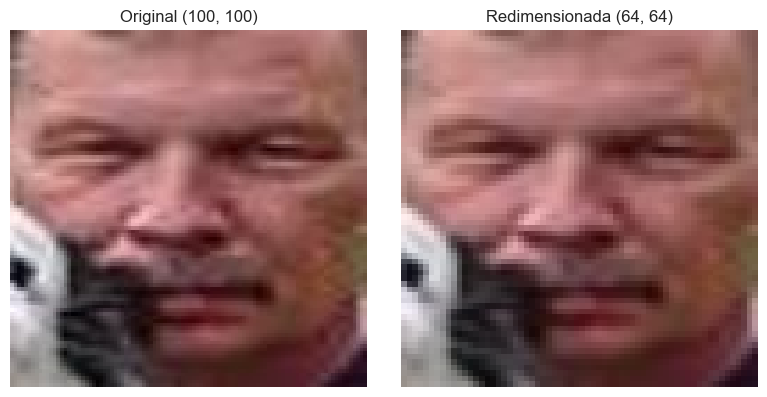

In [115]:
# --- Redimensionamiento ---

if APLICAR_REDIMENSIONAMIENTO:
    _resize = transforms.Resize(TAMANO_IMAGEN)
    transforms_train.append(_resize)
    transforms_val.append(_resize)
    print(f"Redimensionamiento activo → {TAMANO_IMAGEN}")
else:
    print("Redimensionamiento desactivado")

# Vista previa: comparar original vs redimensionada
if APLICAR_REDIMENSIONAMIENTO:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        img_redimensionada = _resize(img_original)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_original)
        axes[0].set_title(f"Original {img_original.size}")
        axes[0].axis("off")
        axes[1].imshow(img_redimensionada)
        axes[1].set_title(f"Redimensionada {img_redimensionada.size}")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.4 Color o escala de grises

Define si el modelo recibe imágenes en **escala de grises** (1 canal) o en **RGB** (3 canales). Se controla con `MODO_COLOR` en la celda de configuración:

- `"grayscale"`: aplica `torchvision.transforms.Grayscale`.
- `"rgb"`: mantiene color; convierte la imagen a RGB por si el archivo viene en otro modo (L, RGBA, etc.).

El número de canales (`NUM_CANALES_ENTRADA`) y los parámetros de normalización se ajustan automáticamente.


Modo de color activo: escala de grises → 1 canal


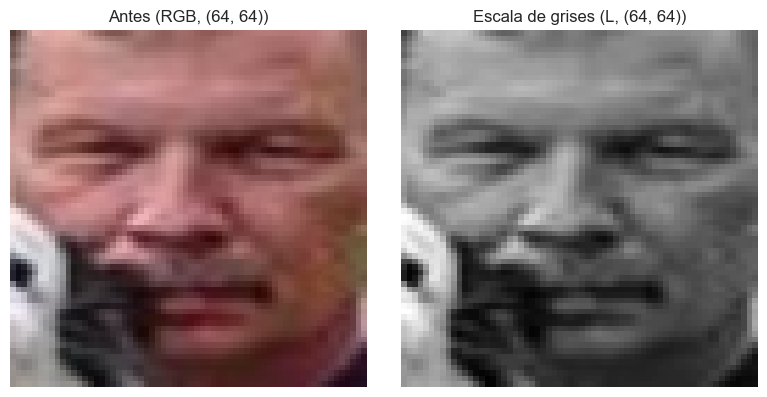

In [116]:
# --- Color o escala de grises ---

def _asegurar_rgb(img):
    return img.convert("RGB")


if MODO_COLOR == "grayscale":
    _transform_color = transforms.Grayscale(num_output_channels=1)
    transforms_train.append(_transform_color)
    transforms_val.append(_transform_color)
    print(f"Modo de color activo: escala de grises → {NUM_CANALES_ENTRADA} canal")
else:
    _transform_color = transforms.Lambda(_asegurar_rgb)
    transforms_train.append(_transform_color)
    transforms_val.append(_transform_color)
    print(f"Modo de color activo: RGB → {NUM_CANALES_ENTRADA} canales")

# Vista previa: comparar antes vs después del modo de color elegido
muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
if muestra is None:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

if muestra is not None:
    img_original = Image.open(muestra)
    _pipeline_previo = transforms.Compose(transforms_train[:-1]) if len(transforms_train) > 1 else None
    img_antes = _pipeline_previo(img_original) if _pipeline_previo else img_original
    img_despues = _transform_color(img_antes)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_antes, cmap="gray" if img_antes.mode == "L" else None)
    axes[0].set_title(f"Antes ({img_antes.mode}, {img_antes.size})")
    axes[0].axis("off")

    if MODO_COLOR == "grayscale":
        axes[1].imshow(img_despues, cmap="gray")
        axes[1].set_title(f"Escala de grises ({img_despues.mode}, {img_despues.size})")
    else:
        axes[1].imshow(img_despues)
        axes[1].set_title(f"RGB ({img_despues.mode}, {img_despues.size})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")


### 1.5 Normalización

Convierte la imagen a tensor en rango [0, 1] con `ToTensor` y luego escala con `Normalize` usando media y desviación estándar por canal. Con `mean=[0.5]` y `std=[0.5]` (gris) o `mean=[0.5, 0.5, 0.5]` (RGB) los valores quedan aproximadamente en [-1, 1]. Los valores de `NORMALIZE_MEAN` y `NORMALIZE_STD` se definen automáticamente según `MODO_COLOR`.


Normalización activa → mean=[0.5], std=[0.5]


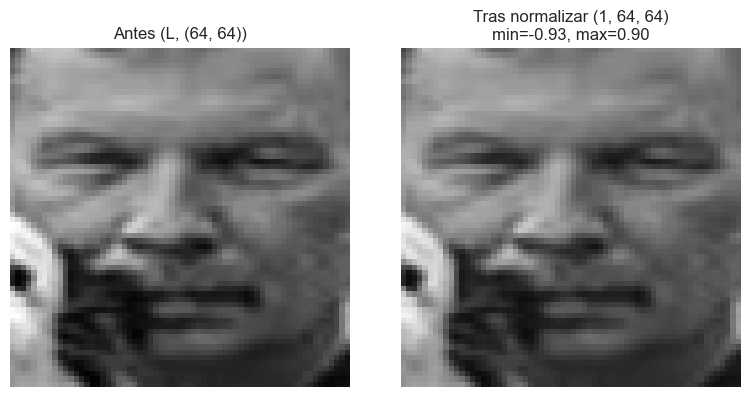

In [117]:
# --- Normalización ---

if APLICAR_NORMALIZACION:
    _to_tensor = transforms.ToTensor()
    _normalize = transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
    transforms_train.extend([_to_tensor, _normalize])
    transforms_val.extend([_to_tensor, _normalize])
    print(f"Normalización activa → mean={NORMALIZE_MEAN}, std={NORMALIZE_STD}")
else:
    print("Normalización desactivada")

# Vista previa: imagen antes vs tensor normalizado
if APLICAR_NORMALIZACION:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        _pipeline_previo = transforms.Compose(transforms_train[:-2]) if len(transforms_train) > 2 else None
        img_antes = _pipeline_previo(img_original) if _pipeline_previo else img_original
        tensor_norm = _normalize(_to_tensor(img_antes))

        def _desnormalizar(tensor):
            t = tensor.clone()
            for c in range(t.shape[0]):
                t[c] = t[c] * NORMALIZE_STD[c] + NORMALIZE_MEAN[c]
            return t

        img_restaurada = _desnormalizar(tensor_norm)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_antes, cmap="gray" if img_antes.mode == "L" else None)
        axes[0].set_title(f"Antes ({img_antes.mode}, {img_antes.size})")
        axes[0].axis("off")

        if img_restaurada.shape[0] == 1:
            axes[1].imshow(img_restaurada.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        else:
            axes[1].imshow(img_restaurada.permute(1, 2, 0).numpy(), vmin=0, vmax=1)
        axes[1].set_title(
            f"Tras normalizar {tuple(tensor_norm.shape)}\n"
            f"min={tensor_norm.min():.2f}, max={tensor_norm.max():.2f}"
        )
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.6 Aumento de datos

Genera variaciones aleatorias **solo en entrenamiento** para mejorar la generalización. Las transformaciones se insertan antes de `ToTensor` y `Normalize`. Se controlan de forma independiente con las variables `APLICAR_*` de la celda de configuración.

**E5 (`RandomRotation ±10°`):** probado y descartado vs E4 (F1 68.8% vs 69.7%). Config activa: sin rotación.


Aumento de datos activo (solo transforms_train):
  - RandomHorizontalFlip
  - ColorJitter


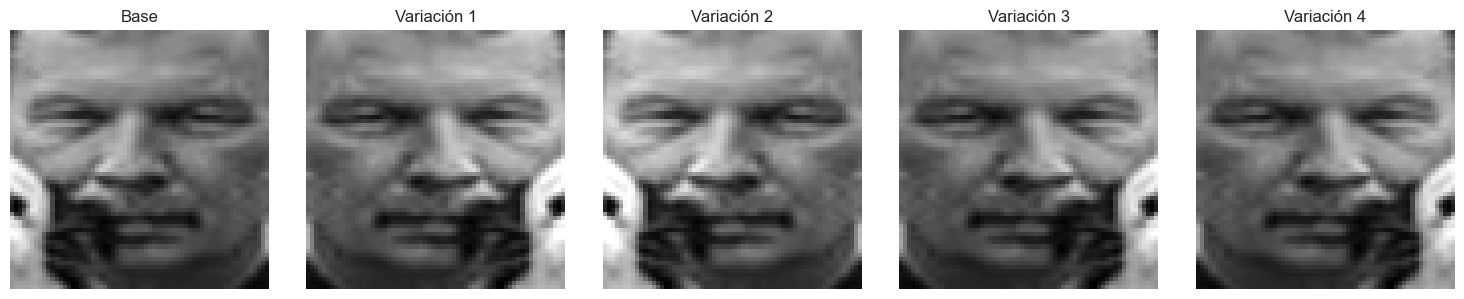

In [118]:
# --- Aumento de datos ---

_augmentaciones = []
_mensajes = []

if APLICAR_VOLTEO_HORIZONTAL:
    _augmentaciones.append(transforms.RandomHorizontalFlip())
    _mensajes.append("RandomHorizontalFlip")

if APLICAR_ROTACION:
    _augmentaciones.append(transforms.RandomRotation(ROTACION_GRADOS))
    _mensajes.append(f"RandomRotation({ROTACION_GRADOS}°)")

if APLICAR_RECORTE_ALEATORIO:
    _augmentaciones.append(transforms.RandomCrop(RECORTE_TAMANO))
    _mensajes.append(f"RandomCrop{RECORTE_TAMANO}")

if APLICAR_COLOR_JITTER:
    _augmentaciones.append(transforms.ColorJitter(
        brightness=COLOR_JITTER_BRIGHTNESS,
        contrast=COLOR_JITTER_CONTRAST,
    ))
    _mensajes.append("ColorJitter")

if _augmentaciones:
    _idx_insercion = next(
        (i for i, t in enumerate(transforms_train) if isinstance(t, transforms.ToTensor)),
        len(transforms_train),
    )
    for i, aug in enumerate(_augmentaciones):
        transforms_train.insert(_idx_insercion + i, aug)
    print("Aumento de datos activo (solo transforms_train):")
    for msg in _mensajes:
        print(f"  - {msg}")
else:
    print("Aumento de datos desactivado")

# Vista previa: imagen base vs variaciones aleatorias
if _augmentaciones:
    muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.jpg"), None)
    if muestra is None:
        muestra = next(Path(DATASET_ROOT_TRAIN).rglob("*.png"), None)

    if muestra is not None:
        img_original = Image.open(muestra)
        _pipeline_base = transforms.Compose(transforms_train[:_idx_insercion])
        _pipeline_aug = transforms.Compose(transforms_train[:_idx_insercion] + _augmentaciones)
        img_base = _pipeline_base(img_original)

        n_variaciones = 4
        fig, axes = plt.subplots(1, n_variaciones + 1, figsize=(3 * (n_variaciones + 1), 3))
        axes[0].imshow(img_base, cmap="gray" if img_base.mode == "L" else None)
        axes[0].set_title("Base")
        axes[0].axis("off")

        for i in range(n_variaciones):
            img_aug = _pipeline_aug(img_original)
            axes[i + 1].imshow(img_aug, cmap="gray" if img_aug.mode == "L" else None)
            axes[i + 1].set_title(f"Variación {i + 1}")
            axes[i + 1].axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró imagen de ejemplo en el dataset de entrenamiento.")

### 1.7 Balanceo de datos

Si las clases están desbalanceadas, se puede compensar en el entrenamiento con **oversampling** mediante `WeightedRandomSampler` de PyTorch. No es una transformación de imagen: define cómo se eligen las muestras en el `DataLoader` de entrenamiento.

**E6:** `APLICAR_BALANCEO = False` — el desbalance se corrige solo con pesos en la loss (no acumular sampler + loss como en E2).


In [119]:
# --- Balanceo de datos ---

train_sampler = None


def _contar_imagenes(carpeta):
    total = 0
    for extension in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
        total += len(list(carpeta.glob(extension)))
    return total


clases = sorted(p.name for p in Path(DATASET_ROOT_TRAIN).iterdir() if p.is_dir())
conteo_por_clase = {
    clase: _contar_imagenes(Path(DATASET_ROOT_TRAIN) / clase) for clase in clases
}

if APLICAR_BALANCEO:
    pesos_por_clase = {clase: 1.0 / conteo for clase, conteo in conteo_por_clase.items() if conteo > 0}
    pesos_muestra = []

    for clase in clases:
        peso = pesos_por_clase.get(clase)
        if peso is None:
            continue
        carpeta_clase = Path(DATASET_ROOT_TRAIN) / clase
        for extension in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for _ in carpeta_clase.glob(extension):
                pesos_muestra.append(peso)

    if pesos_muestra:
        train_sampler = WeightedRandomSampler(
            weights=pesos_muestra,
            num_samples=len(pesos_muestra),
            replacement=True,
        )
        print("Balanceo activo → WeightedRandomSampler (oversampling de clases minoritarias)")
        print("Conteo por clase en entrenamiento:")
        for clase in clases:
            print(f"  - {clase}: {conteo_por_clase[clase]}")
    else:
        print("Balanceo desactivado: no se encontraron imágenes en el dataset de entrenamiento.")
else:
    print("Balanceo desactivado")
    print("Conteo por clase en entrenamiento:")
    for clase in clases:
        print(f"  - {clase}: {conteo_por_clase[clase]}")

# Vista previa: distribución original vs frecuencia esperada tras balanceo
if APLICAR_BALANCEO and pesos_muestra:
    frecuencia_esperada = {clase: pesos_por_clase[clase] * conteo_por_clase[clase] for clase in clases if conteo_por_clase[clase] > 0}
    total_esperado = sum(frecuencia_esperada.values())
    frecuencia_esperada = {clase: valor / total_esperado for clase, valor in frecuencia_esperada.items()}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(conteo_por_clase.keys(), conteo_por_clase.values())
    axes[0].set_title("Distribución original (train)")
    axes[0].set_xlabel("Clase")
    axes[0].set_ylabel("Cantidad de imágenes")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(frecuencia_esperada.keys(), frecuencia_esperada.values())
    axes[1].set_title("Frecuencia esperada por clase tras balanceo")
    axes[1].set_xlabel("Clase")
    axes[1].set_ylabel("Proporción")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


Balanceo desactivado
Conteo por clase en entrenamiento:
  - alegria: 4772
  - disgusto: 717
  - enojo: 705
  - miedo: 281
  - seriedad: 2524
  - sorpresa: 1290
  - tristeza: 1982


### 1.8 Decisiones de preprocesamiento

> **⚠️ REVISAR ANTES DE LA ENTREGA:** este apartado documenta la config **E6** (modelo final). Tras cualquier cambio en §1.2 o §2, re-ejecutar la celda siguiente y verificar coherencia con `reporte-experimentos.md` y los outputs de §3.

La celda siguiente **genera automáticamente** el resumen de decisiones a partir de las variables definidas en §1.2 (`APLICAR_*`, `MODO_COLOR`, etc.). Ejecutarla después de cualquier cambio en la configuración garantiza que la documentación y el pipeline coincidan.


In [120]:
# --- Decisiones de preprocesamiento (generado desde la config de §1.2) ---
from IPython.display import Markdown, display


def _generar_decisiones_preprocesamiento():
    lineas = [
        "### 1.8 Decisiones de preprocesamiento\n",
        "\n",
        "A continuación se resume el pipeline elegido para el clasificador de emociones faciales, "
        "en función del dataset disponible (rostros alineados, clases desbalanceadas e imágenes de baja resolución).\n",
        "\n",
        "Este texto se **genera automáticamente** desde las variables de configuración de §1.2.\n",
        "\n",
        "> **⚠️ REVISAR ANTES DE LA ENTREGA:** validar redacción, métricas E6 y alineación con §2 antes de entregar el Colab.\n",
        "\n",
        "#### Técnicas aplicadas\n",
        "\n",
    ]

    aplicadas = []
    descartadas = []

    if APLICAR_REDIMENSIONAMIENTO:
        alto, ancho = TAMANO_IMAGEN
        aplicadas.append(
            f"- **Redimensionamiento a {alto}×{ancho} píxeles:** se uniformizó el tamaño de entrada porque el dataset "
            "utiliza imágenes en esa resolución y la CNN requiere dimensiones fijas. No se preservó la relación "
            "de aspecto de forma explícita; dado que las imágenes del conjunto ya son rostros centrados y "
            "aproximadamente cuadrados (`*_aligned.jpg`), se consideró aceptable un `Resize` directo."
        )
    else:
        descartadas.append("- **Redimensionamiento:** no se activó.")

    if MODO_COLOR == "grayscale":
        aplicadas.append(
            '- **Escala de grises (`MODO_COLOR = "grayscale"`):** se convirtieron las imágenes a un canal '
            "para reducir dimensionalidad y enfocar el aprendizaje en forma, contraste y texturas faciales, "
            "variables relevantes para distinguir emociones en este tipo de imágenes."
        )
        descartadas.append(
            '- **Modo RGB:** no se utilizó en esta configuración; queda disponible mediante '
            '`MODO_COLOR = "rgb"` para experimentos comparativos.'
        )
    else:
        aplicadas.append(
            '- **RGB (`MODO_COLOR = "rgb"`):** se mantuvo el color en tres canales para evaluar si la '
            "información cromática aporta señal adicional en la clasificación de emociones."
        )
        descartadas.append(
            '- **Escala de grises:** no se utilizó; queda disponible mediante '
            '`MODO_COLOR = "grayscale"`.'
        )

    if APLICAR_NORMALIZACION:
        mean_str = ", ".join(f"{v:g}" for v in NORMALIZE_MEAN)
        std_str = ", ".join(f"{v:g}" for v in NORMALIZE_STD)
        n_canales = len(NORMALIZE_MEAN)
        aplicadas.append(
            f"- **Normalización:** se aplicó `ToTensor` seguido de `Normalize` con media [{mean_str}] "
            f"y desviación estándar [{std_str}] ({n_canales} canal/es), escalando los valores "
            "aproximadamente al rango [-1, 1] para estabilizar el entrenamiento."
        )
    else:
        descartadas.append("- **Normalización:** no se activó.")

    augs_train = []
    if APLICAR_VOLTEO_HORIZONTAL:
        augs_train.append(
            "**volteo horizontal aleatorio**, asumiendo simetría aproximada del rostro para expresiones frontales"
        )
    else:
        descartadas.append("- **Volteo horizontal:** no se activó.")

    if APLICAR_ROTACION:
        augs_train.append(f"**rotación aleatoria** (±{ROTACION_GRADOS}°)")
    else:
        descartadas.append(
            f"- **Rotación aleatoria (±{ROTACION_GRADOS}°):** no se activó, para no introducir inclinaciones "
            "que distorsionen la geometría facial en rostros ya alineados."
        )

    if APLICAR_RECORTE_ALEATORIO:
        rh, rw = RECORTE_TAMANO
        augs_train.append(f"**recorte aleatorio** ({rh}×{rw} píxeles)")
    else:
        rh, rw = RECORTE_TAMANO
        descartadas.append(
            f"- **Recorte aleatorio ({rh}×{rw}):** no se activó, ya que podría recortar regiones relevantes "
            "(ojos, boca) en imágenes de baja resolución."
        )

    if APLICAR_COLOR_JITTER:
        augs_train.append(
            f"**ColorJitter** (brillo={COLOR_JITTER_BRIGHTNESS}, contraste={COLOR_JITTER_CONTRAST}) "
            "para simular variaciones de iluminación"
        )
    else:
        descartadas.append("- **ColorJitter:** no se activó.")

    if augs_train:
        bloque_aug = ["- **Aumento de datos (solo entrenamiento):**"]
        for aug in augs_train:
            bloque_aug.append(f"  - Se activó {aug}.")
        aplicadas.append("\n".join(bloque_aug))

    if APLICAR_BALANCEO:
        aplicadas.append(
            "- **Balanceo de clases:** se activó **WeightedRandomSampler** en entrenamiento para compensar "
            "el desbalance del dataset (p. ej. alegría y seriedad con muchas más muestras que miedo o disgusto), "
            "evitando que el modelo sesgue hacia las clases mayoritarias."
        )
    else:
        if DOCUMENTAR_PESOS_EN_LOSS:
            descartadas.append(
                "- **Balanceo de clases (WeightedRandomSampler):** no se activó (config **E6**). "
                "La compensación del desbalance se realiza con **pesos en la CrossEntropyLoss** "
                f"(`{DOCUMENTAR_MODO_PESOS_CLASE}`), evitando la doble compensación que empeoró el experimento E2."
            )
        else:
            descartadas.append(
                "- **Balanceo de clases (WeightedRandomSampler):** no se activó; el modelo puede sesgarse "
                "hacia las clases mayoritarias."
            )

    lineas.extend(ap + "\n\n" for ap in aplicadas)
    lineas.append("#### Técnicas descartadas o no aplicadas\n\n")
    lineas.extend(d + "\n\n" for d in descartadas)

    if EXPERIMENTO_FINAL == "E6" and METRICAS_VALIDACION_FINAL:
        m = METRICAS_VALIDACION_FINAL
        lineas.extend([
            "#### Configuración final del modelo (E6)\n\n",
            "Resumen del experimento seleccionado para entrega (detalle en `reporte-experimentos.md`):\n\n",
            "- **Preprocesamiento:** 64×64, escala de grises, normalización 0.5/0.5, flip horizontal + ColorJitter; "
            "sin rotación ni recorte aleatorio; **sin** `WeightedRandomSampler`.\n",
            f"- **Entrenamiento:** CNN 32-64-128, FC 256, dropout 0.5, Adam lr=1e-4, early stopping en `val_f1` "
            f"(patience 5), **CrossEntropyLoss ponderada** (`{DOCUMENTAR_MODO_PESOS_CLASE}`).\n",
            f"- **Métricas en validación (mejor época {m['mejor_epoca']}, parada ép. {m['parada']}):** "
            f"accuracy **{m['accuracy'] * 100:.2f}%**, F1 macro **{m['f1_macro'] * 100:.2f}%**, loss **{m['loss']:.4f}**.\n",
            "- **Campaña:** E0 baseline → E1 (early stopping `val_f1`) → E4 (64×64) → **E6** (loss sin sampler). "
            "Descartados: E2 (sampler+loss), E3 (dropout 0.6), E5 (rotación ±10°).\n\n",
        ])

    lineas.extend([
        "#### Pipeline de inferencia\n\n",
        "En validación e inferencia (secciones 4 y 5) se utiliza el pipeline `transform_val`, "
        "sin augmentations ni balanceo: las transformaciones configuradas en §1.3–§1.5 que integran "
        "`transforms_val`. En el punto 5 se agrega previamente detección y recorte de rostro con Haar Cascade "
        "antes de aplicar el mismo preprocesamiento de validación.\n",
    ])
    return "".join(lineas)


_texto_decisiones = _generar_decisiones_preprocesamiento()
display(Markdown(_texto_decisiones))
print("§1.8 generado desde la configuración actual de §1.2.")


### 1.8 Decisiones de preprocesamiento

A continuación se resume el pipeline elegido para el clasificador de emociones faciales, en función del dataset disponible (rostros alineados, clases desbalanceadas e imágenes de baja resolución).

Este texto se **genera automáticamente** desde las variables de configuración de §1.2.

> **⚠️ REVISAR ANTES DE LA ENTREGA:** validar redacción, métricas E6 y alineación con §2 antes de entregar el Colab.

#### Técnicas aplicadas

- **Redimensionamiento a 64×64 píxeles:** se uniformizó el tamaño de entrada porque el dataset utiliza imágenes en esa resolución y la CNN requiere dimensiones fijas. No se preservó la relación de aspecto de forma explícita; dado que las imágenes del conjunto ya son rostros centrados y aproximadamente cuadrados (`*_aligned.jpg`), se consideró aceptable un `Resize` directo.

- **Escala de grises (`MODO_COLOR = "grayscale"`):** se convirtieron las imágenes a un canal para reducir dimensionalidad y enfocar el aprendizaje en forma, contraste y texturas faciales, variables relevantes para distinguir emociones en este tipo de imágenes.

- **Normalización:** se aplicó `ToTensor` seguido de `Normalize` con media [0.5] y desviación estándar [0.5] (1 canal/es), escalando los valores aproximadamente al rango [-1, 1] para estabilizar el entrenamiento.

- **Aumento de datos (solo entrenamiento):**
  - Se activó **volteo horizontal aleatorio**, asumiendo simetría aproximada del rostro para expresiones frontales.
  - Se activó **ColorJitter** (brillo=0.2, contraste=0.2) para simular variaciones de iluminación.

#### Técnicas descartadas o no aplicadas

- **Modo RGB:** no se utilizó en esta configuración; queda disponible mediante `MODO_COLOR = "rgb"` para experimentos comparativos.

- **Rotación aleatoria (±10°):** no se activó, para no introducir inclinaciones que distorsionen la geometría facial en rostros ya alineados.

- **Recorte aleatorio (56×56):** no se activó, ya que podría recortar regiones relevantes (ojos, boca) en imágenes de baja resolución.

- **Balanceo de clases (WeightedRandomSampler):** no se activó (config **E6**). La compensación del desbalance se realiza con **pesos en la CrossEntropyLoss** (`sqrt_inverso`), evitando la doble compensación que empeoró el experimento E2.

#### Configuración final del modelo (E6)

Resumen del experimento seleccionado para entrega (detalle en `reporte-experimentos.md`):

- **Preprocesamiento:** 64×64, escala de grises, normalización 0.5/0.5, flip horizontal + ColorJitter; sin rotación ni recorte aleatorio; **sin** `WeightedRandomSampler`.
- **Entrenamiento:** CNN 32-64-128, FC 256, dropout 0.5, Adam lr=1e-4, early stopping en `val_f1` (patience 5), **CrossEntropyLoss ponderada** (`sqrt_inverso`).
- **Métricas en validación (mejor época 29, parada ép. 34):** accuracy **79.34%**, F1 macro **71.30%**, loss **0.6097**.
- **Campaña:** E0 baseline → E1 (early stopping `val_f1`) → E4 (64×64) → **E6** (loss sin sampler). Descartados: E2 (sampler+loss), E3 (dropout 0.6), E5 (rotación ±10°).

#### Pipeline de inferencia

En validación e inferencia (secciones 4 y 5) se utiliza el pipeline `transform_val`, sin augmentations ni balanceo: las transformaciones configuradas en §1.3–§1.5 que integran `transforms_val`. En el punto 5 se agrega previamente detección y recorte de rostro con Haar Cascade antes de aplicar el mismo preprocesamiento de validación.


§1.8 generado desde la configuración actual de §1.2.


## 2- Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

### 2.1 Arquitectura CNN recomendada

Propuesta para imágenes **48×48** en **escala de grises (1 canal) o RGB (3 canales)** — según `MODO_COLOR` — y **7 clases** de emoción, construida desde cero con PyTorch.

#### Diseño general

| Bloque | Capas | Salida espacial |
|---|---|---|
| Entrada | — | C × H × W (C=1 gris o C=3 RGB) |
| Conv 1 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 32 × 24 × 24 |
| Conv 2 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 64 × 12 × 12 |
| Conv 3 | Conv2d → BatchNorm → ReLU → MaxPool(2) | 128 × 6 × 6 |
| Clasificador | Flatten → Linear → ReLU → Dropout → Linear | 7 logits |

**Parámetros convolucionales:**
- **3 bloques convolucionales** con filtros crecientes (32 → 64 → 128): suficiente profundidad para capturar bordes, texturas y patrones faciales en imágenes pequeñas, sin hacer la red tan grande que sobreajuste fácilmente.
- **Kernels 3×3** con `padding=1`: tamaño estándar para detectar patrones locales (ojos, boca, arrugas); mantiene dimensiones antes del pooling y usa menos parámetros que kernels 5×5.
- **MaxPooling 2×2**: reduce la resolución espacial, aporta invarianza a pequeños desplazamientos y disminuye el costo computacional.
- **BatchNorm** después de cada convolución: estabiliza el entrenamiento y permite usar learning rates un poco más altos.

**Capas fully connected:**
- **Linear(4608 → 256)**: condensa las características extraídas.
- **Dropout(0.5)**: regulariza y reduce overfitting.
- **Linear(256 → 7)**: capa de salida (una unidad por emoción).

#### Funciones de activación

| Capa | Activación | Justificación |
|---|---|---|
| Convolucionales | **ReLU** | Evita el desvanecimiento del gradiente, es computacionalmente eficiente y produce activaciones dispersas, útil para detectar rasgos presentes/ausentes. |
| Fully connected oculta | **ReLU** | Misma razón; mantiene coherencia en toda la red. |
| Salida | **Sin activación (logits)** | `CrossEntropyLoss` ya aplica softmax internamente; aplicar softmax antes duplicaría la operación y puede empeorar la estabilidad numérica. |

#### Función de costo, optimizador y learning rate

| Hiperparámetro | Valor recomendado | Justificación |
|---|---|---|
| **Función de costo** | `CrossEntropyLoss` | Clasificación multiclase mutuamente excluyente (cada imagen tiene una sola emoción). |
| **Optimizador** | **Adam** (`lr=1e-3`) | Adapta el learning rate por parámetro; converge bien en CNNs pequeñas sin ajuste fino extenso. Alternativa válida: SGD con momentum (`lr=1e-2`, `momentum=0.9`). |
| **Learning rate** | **0.001** | Punto de partida habitual para Adam en redes entrenadas desde cero. Si la loss oscila, bajar a `3e-4`; si converge muy lento, probar `3e-3`. |
| **Batch size** | **32 o 64** | Balance entre estabilidad del gradiente y uso de memoria en Colab. |
| **Épocas** | **30–50** | Con early stopping o monitoreo de validación para evitar overfitting. |

Esta arquitectura es un punto de partida razonable para el dataset de emociones faciales. Los hiperparámetros pueden ajustarse según los resultados de validación.

### 2.2 Función de costo ponderada por clase (E2)

El `WeightedRandomSampler` (§1.7) **equilibra qué imágenes entran en cada batch**, pero la `CrossEntropyLoss` sin pesos **penaliza por igual** todos los errores de clasificación.

| Mecanismo | Qué corrige |
|-----------|-------------|
| Sampler (balanceo) | Frecuencia de muestreo en el batch |
| Loss ponderada | Penalización del error al predecir mal una clase |
| Early stopping `val_f1` | Elección del checkpoint según F1 macro |

**E2 (`sqrt_inverso` + sampler):** regresión vs E1 (F1 macro 66.0% vs 69.5%) — doble compensación.

**E6 (ablation):** loss `sqrt_inverso` **sin** sampler — un solo mecanismo de compensación de desbalance.


### 2.3 Regularización — dropout en capa FC (E3)

**Base experimental:** E1 (`EARLY_STOPPING_METRICA = "val_f1"`, balanceo activo, `CrossEntropyLoss` sin pesos).

**Cambio único:** `DROPOUT_FC = 0.6` (antes `0.5` en E0/E1).

En E0 y E1 el entrenamiento supera claramente a la validación a partir de la mejor época (p. ej. train acc ~85% vs val ~77% en E1, ép. 16) — **overfitting moderado** en la capa fully connected, donde el modelo concentra la mayor capacidad discriminativa tras el flatten convolucional.

El dropout apaga neuronas al azar durante el entrenamiento y obliga a representaciones más robustas. Subir de 0.5 a 0.6 es un incremento conservador: suficiente para reducir memorización sin impedir que aprenda clases difíciles (disgusto, miedo).

| Experimento | Dropout FC | Objetivo |
|-------------|------------|----------|
| E1 (referencia) | 0.5 | Mejor resultado actual (F1 macro 69.5%) |
| **E3** | **0.6** | No superó E1 (F1 68.4% vs 69.5%) |

E3b (`weight_decay`) quedó pospuesto; la base activa vuelve a **E1** (dropout 0.5).


### 2.4 Resolución de entrada 64×64 (E4)

**Base experimental:** E1 — `EARLY_STOPPING_METRICA = "val_f1"`, balanceo activo, `CrossEntropyLoss` sin pesos, `DROPOUT_FC = 0.5`.

**Cambio único:** `TAMANO_IMAGEN = (64, 64)` (E0–E3 usaban 48×48).

En E1 las clases más débiles (disgusto F1 0.51, miedo 0.58) comparten rasgos finos con seriedad/sorpresa que se pierden a **48 píxeles**. Subir a 64×64 conserva más información de ojos, boca y cejas sin cambiar arquitectura ni hiperparámetros de entrenamiento.

La capa FC se adapta sola: `EmotionCNN` infiere el tamaño del flatten con un forward dummy sobre `TAMANO_IMAGEN` (mapa conv final 8×8 con 128 filtros → 8192 features vs 3×3/1152 en 48×48).

| Experimento | Resolución | F1 macro (val) |
|-------------|------------|----------------|
| E1 (referencia) | 48×48 | **69.5%** |
| **E4** | **64×64** | **69.7%** |

**Inferencia (§4–§5):** usar el mismo `transform_val` re-ejecutado tras §1.3; no requiere cambios manuales en Haar si se aplica `Resize` al rostro recortado.


### 2.5 Rotación aleatoria suave (E5)

**Base experimental:** E4 — 64×64, gris, flip horizontal + ColorJitter, balanceo, early stopping `val_f1`, dropout 0.5, loss sin pesos.

**Cambio único:** `APLICAR_ROTACION = True`, `ROTACION_GRADOS = 10` (antes desactivado en E0–E4).

Hasta E4 las únicas augmentations geométricas eran volteo horizontal; la rotación introduce variabilidad de inclinación leve sin distorsionar demasiado rostros ya alineados (`*_aligned.jpg`). **±10°** es un compromiso: más generalización que 0°, menos riesgo que ±15° de recortar rasgos en bordes.

| Experimento | Augmentations train | F1 macro (val) |
|-------------|---------------------|----------------|
| E4 (referencia) | flip + ColorJitter | **69.7%** |
| **E5** | flip + ColorJitter + RandomRotation(±10°) | 68.8% (descartado) |

Validación e inferencia siguen sin rotación (`transform_val`).


### 2.6 Loss ponderada sin sampler (E6)

**Base experimental:** E4 — 64×64, gris, flip + ColorJitter, **sin rotación**, early stopping `val_f1`, dropout 0.5.

**Cambios vs E4 (dos flags, un solo mecanismo):**
- `APLICAR_BALANCEO = False` — entrenamiento con muestreo natural (alegría domina los batches)
- `APLICAR_PESOS_EN_LOSS = True`, `MODO_PESOS_CLASE = "sqrt_inverso"` — penalizar más errores en clases minoritarias

E2 falló por **doble compensación** (sampler + loss). E6 aísla la loss ponderada: el objetivo de entrenamiento sigue alineado con F1 macro sin oversampling artificial.

| Experimento | Balanceo | Loss ponderada | F1 macro (val) |
|-------------|----------|----------------|----------------|
| E4 (referencia) | sampler | no | **69.7%** |
| E2 | sampler | sí (`sqrt_inverso`) | 66.0% (descartado) |
| **E6** | **no** | **sí (`sqrt_inverso`)** | **71.3%** (acc 79.3%) |

> **⚠️ REVISAR ANTES DE LA ENTREGA:** E6 es la config final. Verificar coherencia con outputs de §3 y `reporte-experimentos.md`.

Re-ejecutar §1.7–§1.8 y §2 antes de entrenar. En §1.7 debe decir "Balanceo desactivado"; en §2 deben listarse los pesos por clase.


In [121]:
import torch.nn as nn

# --- Configuración de arquitectura ---
# NUM_CANALES_ENTRADA se define en la celda de configuración (MODO_COLOR)
NUM_CLASES = len([p for p in Path(DATASET_ROOT_TRAIN).iterdir() if p.is_dir()])

FILTROS_CONV = [32, 64, 128]
TAMANO_KERNEL = 3
PADDING_CONV = 1
TAMANO_POOL = 2
UNIDADES_FC_OCULTAS = 256
DROPOUT_FC = 0.5  # base E1 (E3 probó 0.6 → peor F1 macro)

# --- Configuración de entrenamiento ---
BATCH_SIZE = 32
NUM_EPOCHS = 40
#LEARNING_RATE = 1e-3
LEARNING_RATE = 1e-4
OPTIMIZADOR = "adam"  # "adam" o "sgd"
SGD_MOMENTUM = 0.9

# --- Early Stopping ---
APLICAR_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 5          # épocas sin mejora antes de detener
EARLY_STOPPING_MIN_DELTA = 0.0       # mejora mínima requerida para resetear el contador
EARLY_STOPPING_METRICA = "val_f1"  # "val_loss", "val_acc" o "val_f1"
EARLY_STOPPING_RESTAURAR_MEJOR_MODELO = True  # cargar los pesos de la mejor época al finalizar

# --- Función de costo (E2: pesos por clase) ---
APLICAR_PESOS_EN_LOSS = True  # E6: loss sqrt_inverso sin sampler
# "sqrt_inverso" (E6) | "balanceado" | "inverso"
MODO_PESOS_CLASE = "sqrt_inverso"


def _crear_bloque_conv(canales_entrada, canales_salida):
    return nn.Sequential(
        nn.Conv2d(canales_entrada, canales_salida, TAMANO_KERNEL, padding=PADDING_CONV),
        nn.BatchNorm2d(canales_salida),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(TAMANO_POOL),
    )


class EmotionCNN(nn.Module):
    """CNN desde cero para clasificación de emociones (sin modelos pre-entrenados)."""

    def __init__(
        self,
        num_canales=NUM_CANALES_ENTRADA,
        num_clases=NUM_CLASES,
        filtros=FILTROS_CONV,
        unidades_fc=UNIDADES_FC_OCULTAS,
        dropout=DROPOUT_FC,
    ):
        super().__init__()

        bloques = []
        canales_previos = num_canales
        for filtros_salida in filtros:
            bloques.append(_crear_bloque_conv(canales_previos, filtros_salida))
            canales_previos = filtros_salida
        self.features = nn.Sequential(*bloques)

        with torch.no_grad():
            muestra = torch.zeros(1, num_canales, TAMANO_IMAGEN[0], TAMANO_IMAGEN[1])
            tamano_flat = self.features(muestra).view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Linear(tamano_flat, unidades_fc),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(unidades_fc, num_clases),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# Pipelines finales de preprocesamiento
transform_train = transforms.Compose(transforms_train)
transform_val = transforms.Compose(transforms_val)

# Modelo, función de costo y optimizador
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN().to(device)


def _calcular_pesos_loss(conteo_por_clase, clases_orden, modo):
    import math

    n = len(clases_orden)
    total = sum(conteo_por_clase[c] for c in clases_orden)
    pesos = []
    for clase in clases_orden:
        conteo = conteo_por_clase.get(clase, 0)
        if conteo <= 0:
            pesos.append(0.0)
            continue
        if modo == "balanceado":
            peso = total / (n * conteo)
        elif modo == "sqrt_inverso":
            peso = math.sqrt(total / (n * conteo))
        elif modo == "inverso":
            peso = total / conteo
        else:
            raise ValueError('MODO_PESOS_CLASE debe ser "balanceado", "sqrt_inverso" o "inverso"')
        pesos.append(peso)
    media = sum(pesos) / n if n else 1.0
    return torch.tensor([p / media for p in pesos], dtype=torch.float32)


if APLICAR_PESOS_EN_LOSS:
    if "conteo_por_clase" not in globals() or "clases" not in globals():
        raise RuntimeError("Ejecutá primero la celda §1.7 (balanceo) para obtener conteo_por_clase.")
    _pesos_loss = _calcular_pesos_loss(conteo_por_clase, clases, MODO_PESOS_CLASE)
    criterion = nn.CrossEntropyLoss(weight=_pesos_loss.to(device))
    print(f"Loss: CrossEntropyLoss ponderada ({MODO_PESOS_CLASE})")
    for _clase, _peso in zip(clases, _pesos_loss.tolist()):
        print(f"  - {_clase}: peso={_peso:.4f} (n={conteo_por_clase[_clase]})")
else:
    criterion = nn.CrossEntropyLoss()
    print("Loss: CrossEntropyLoss (sin pesos por clase)")

if OPTIMIZADOR.lower() == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZADOR.lower() == "sgd":
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=SGD_MOMENTUM)
else:
    raise ValueError("OPTIMIZADOR debe ser 'adam' o 'sgd'")

parametros_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Dispositivo: {device}")
print(f"Entrada: {NUM_CANALES_ENTRADA} canal(es) | Clases: {NUM_CLASES}")
print(f"Filtros conv: {FILTROS_CONV} | Kernel: {TAMANO_KERNEL}x{TAMANO_KERNEL} | FC oculta: {UNIDADES_FC_OCULTAS}")
print(f"Optimizador: {OPTIMIZADOR.upper()} | LR: {LEARNING_RATE}")
print(f"Parámetros entrenables: {parametros_entrenables:,}")
print(model)


Loss: CrossEntropyLoss ponderada (sqrt_inverso)
  - alegria: peso=0.4620 (n=4772)
  - disgusto: peso=1.1918 (n=717)
  - enojo: peso=1.2019 (n=705)
  - miedo: peso=1.9038 (n=281)
  - seriedad: peso=0.6352 (n=2524)
  - sorpresa: peso=0.8885 (n=1290)
  - tristeza: peso=0.7168 (n=1982)
Dispositivo: cpu
Entrada: 1 canal(es) | Clases: 7
Filtros conv: [32, 64, 128] | Kernel: 3x3 | FC oculta: 256
Optimizador: ADAM | LR: 0.0001
Parámetros entrenables: 2,192,327
EmotionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runn

## 3- Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


### 3.0 Entrenamiento modelo

In [122]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

try:
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


# --- Datasets y DataLoaders ---
dataset_train = ImageFolder(DATASET_ROOT_TRAIN, transform=transform_train)
dataset_val = ImageFolder(DATASET_ROOT_VAL, transform=transform_val)
class_names = dataset_train.classes

train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=(train_sampler is None),
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print(f"Train: {len(dataset_train)} imágenes | Val: {len(dataset_val)} imágenes")
print(f"Clases: {class_names}")


def _entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_total = 0.0
    etiquetas_todas = []
    predicciones_todas = []

    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        salidas = model(imagenes)
        loss = criterion(salidas, etiquetas)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * imagenes.size(0)
        predicciones_todas.extend(salidas.argmax(dim=1).cpu().numpy())
        etiquetas_todas.extend(etiquetas.cpu().numpy())

    loss_promedio = loss_total / len(loader.dataset)
    accuracy = accuracy_score(etiquetas_todas, predicciones_todas)
    f1_macro = f1_score(etiquetas_todas, predicciones_todas, average="macro", zero_division=0)
    return loss_promedio, accuracy, f1_macro


@torch.no_grad()
def _evaluar_epoch(model, loader, criterion, device):
    model.eval()
    loss_total = 0.0
    etiquetas_todas = []
    predicciones_todas = []

    for imagenes, etiquetas in loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salidas = model(imagenes)
        loss = criterion(salidas, etiquetas)

        loss_total += loss.item() * imagenes.size(0)
        predicciones_todas.extend(salidas.argmax(dim=1).cpu().numpy())
        etiquetas_todas.extend(etiquetas.cpu().numpy())

    loss_promedio = loss_total / len(loader.dataset)
    accuracy = accuracy_score(etiquetas_todas, predicciones_todas)
    f1_macro = f1_score(etiquetas_todas, predicciones_todas, average="macro", zero_division=0)
    return loss_promedio, accuracy, f1_macro, etiquetas_todas, predicciones_todas


def _early_stopping_mejoro(valor_actual, mejor_valor, modo, min_delta):
    if mejor_valor is None:
        return True
    if modo == "min":
        return valor_actual < mejor_valor - min_delta
    return valor_actual > mejor_valor + min_delta


_metricas_early_stopping = {
    "val_loss": "min",
    "val_acc": "max",
    "val_f1": "max",
}
if EARLY_STOPPING_METRICA not in _metricas_early_stopping:
    raise ValueError(
        f"EARLY_STOPPING_METRICA debe ser uno de {list(_metricas_early_stopping)}"
    )
_early_stopping_modo = _metricas_early_stopping[EARLY_STOPPING_METRICA]


# --- Entrenamiento ---
historial_entrenamiento = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
}

mejor_valor = None
mejor_epoca = 0
epochs_sin_mejora = 0
mejor_state = None
detenido_por_early_stopping = False

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_f1 = _entrenar_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, y_val_true, y_val_pred = _evaluar_epoch(model, val_loader, criterion, device)

    historial_entrenamiento["train_loss"].append(train_loss)
    historial_entrenamiento["val_loss"].append(val_loss)
    historial_entrenamiento["train_acc"].append(train_acc)
    historial_entrenamiento["val_acc"].append(val_acc)
    historial_entrenamiento["train_f1"].append(train_f1)
    historial_entrenamiento["val_f1"].append(val_f1)

    metricas_epoca = {
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }
    metrica_actual = metricas_epoca[EARLY_STOPPING_METRICA]

    msg_epoca = (
        f"Época {epoch:02d}/{NUM_EPOCHS} | "
        f"loss: {train_loss:.4f}/{val_loss:.4f} | "
        f"acc: {train_acc:.4f}/{val_acc:.4f} | "
        f"f1: {train_f1:.4f}/{val_f1:.4f}"
    )

    if _early_stopping_mejoro(metrica_actual, mejor_valor, _early_stopping_modo, EARLY_STOPPING_MIN_DELTA):
        mejor_valor = metrica_actual
        mejor_epoca = epoch
        epochs_sin_mejora = 0
        if EARLY_STOPPING_RESTAURAR_MEJOR_MODELO:
            mejor_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        msg_epoca += f" | * mejor {EARLY_STOPPING_METRICA}: {metrica_actual:.4f}"
    elif APLICAR_EARLY_STOPPING:
        epochs_sin_mejora += 1
        msg_epoca += f" | sin mejora: {epochs_sin_mejora}/{EARLY_STOPPING_PATIENCE}"

    print(msg_epoca)

    if APLICAR_EARLY_STOPPING and epochs_sin_mejora >= EARLY_STOPPING_PATIENCE:
        detenido_por_early_stopping = True
        print(
            f"\nEarly stopping: entrenamiento detenido en época {epoch} "
            f"(sin mejora en {EARLY_STOPPING_PATIENCE} épocas consecutivas)"
        )
        break

if EARLY_STOPPING_RESTAURAR_MEJOR_MODELO and mejor_state is not None:
    model.load_state_dict(mejor_state)
    print(
        f"\nModelo restaurado a la mejor época ({mejor_epoca}) "
        f"según {EARLY_STOPPING_METRICA}: {mejor_valor:.4f}"
    )
    val_loss_final, val_acc_final, val_f1_final, y_val_true, y_val_pred = _evaluar_epoch(
        model, val_loader, criterion, device
    )
elif detenido_por_early_stopping:
    print(
        f"\nMejor época registrada: {mejor_epoca} "
        f"({EARLY_STOPPING_METRICA}: {mejor_valor:.4f})"
    )
    val_loss_final = historial_entrenamiento["val_loss"][-1]
    val_acc_final = historial_entrenamiento["val_acc"][-1]
    val_f1_final = historial_entrenamiento["val_f1"][-1]
else:
    val_loss_final = historial_entrenamiento["val_loss"][-1]
    val_acc_final = historial_entrenamiento["val_acc"][-1]
    val_f1_final = historial_entrenamiento["val_f1"][-1]

metricas_val_final = {
    "val_loss": val_loss_final,
    "val_acc": val_acc_final,
    "val_f1": val_f1_final,
    "mejor_epoca": mejor_epoca,
    "detenido_por_early_stopping": detenido_por_early_stopping,
}

# Métricas finales en validación (mejor modelo o última época)
print("\n--- Métricas finales en validación ---")
print(f"Accuracy: {val_acc_final:.4f}")
print(f"F1 macro: {val_f1_final:.4f}")
print(f"Loss: {val_loss_final:.4f}")
if mejor_epoca > 0:
    print(f"Mejor época: {mejor_epoca} | Early stopping: {'sí' if detenido_por_early_stopping else 'no'}")

print("\nClassification report:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, zero_division=0))

print("Matriz de confusión (absoluta):")
print(confusion_matrix(y_val_true, y_val_pred))

matriz_confusion_norm = confusion_matrix(y_val_true, y_val_pred, normalize="true")
print("\nMatriz de confusión (normalizada por fila):")
print(np.round(matriz_confusion_norm, 3))

# Guardado para gráficos y evaluación posterior
etiquetas_val_final = y_val_true
predicciones_val_final = y_val_pred
matriz_confusion_final = confusion_matrix(y_val_true, y_val_pred)
matriz_confusion_norm_final = matriz_confusion_norm

Train: 12271 imágenes | Val: 3068 imágenes
Clases: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Época 01/40 | loss: 1.6157/1.1477 | acc: 0.4643/0.6118 | f1: 0.3049/0.4435 | * mejor val_f1: 0.4435
Época 02/40 | loss: 1.3139/1.0157 | acc: 0.5831/0.6516 | f1: 0.4394/0.5316 | * mejor val_f1: 0.5316
Época 03/40 | loss: 1.1632/0.8991 | acc: 0.6335/0.6861 | f1: 0.5089/0.5618 | * mejor val_f1: 0.5618
Época 04/40 | loss: 1.0774/0.8280 | acc: 0.6570/0.7115 | f1: 0.5458/0.5809 | * mejor val_f1: 0.5809
Época 05/40 | loss: 1.0117/0.8531 | acc: 0.6849/0.6926 | f1: 0.5733/0.6121 | * mejor val_f1: 0.6121
Época 06/40 | loss: 0.9555/0.7587 | acc: 0.6974/0.7282 | f1: 0.5984/0.6133 | * mejor val_f1: 0.6133
Época 07/40 | loss: 0.9155/0.7302 | acc: 0.7104/0.7415 | f1: 0.6090/0.6458 | * mejor val_f1: 0.6458
Época 08/40 | loss: 0.8778/0.7299 | acc: 0.7237/0.7370 | f1: 0.6300/0.6526 | * mejor val_f1: 0.6526
Época 09/40 | loss: 0.8457/0.7080 | acc: 0.7373/0.7539 | f1: 0.6504/0.6

### 3.1 Accuracy

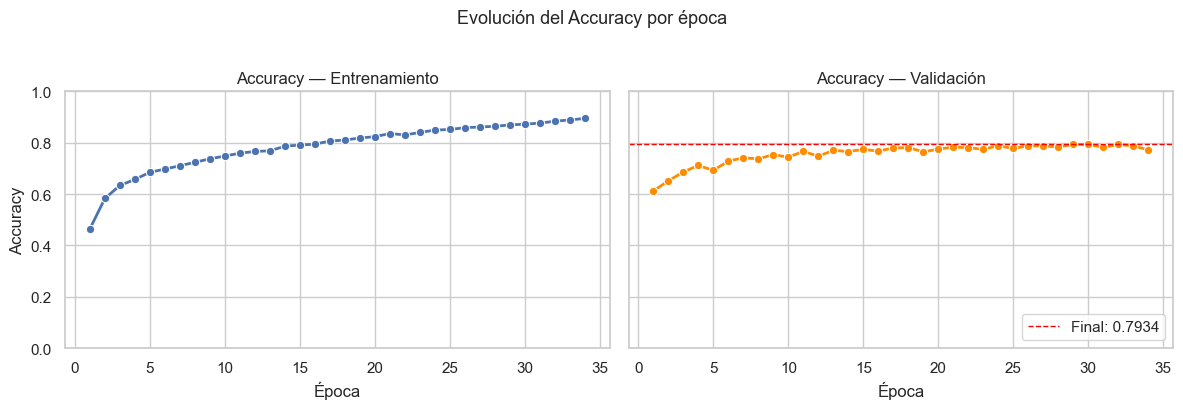

Accuracy final en validación: 0.7934 (79.34%)


In [123]:
try:
    import seaborn as sns
except ModuleNotFoundError:
    _pip_install("seaborn")
    import seaborn as sns

sns.set_theme(style="whitegrid")

accuracy_final_val = metricas_val_final["val_acc"]
epocas = list(range(1, len(historial_entrenamiento["train_acc"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_acc"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Accuracy — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)

sns.lineplot(x=epocas, y=historial_entrenamiento["val_acc"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Accuracy — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].axhline(accuracy_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {accuracy_final_val:.4f}")
axes[1].legend(loc="lower right")

fig.suptitle("Evolución del Accuracy por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Accuracy final en validación: {accuracy_final_val:.4f} ({accuracy_final_val * 100:.2f}%)")

### 3.2 F1 Macro

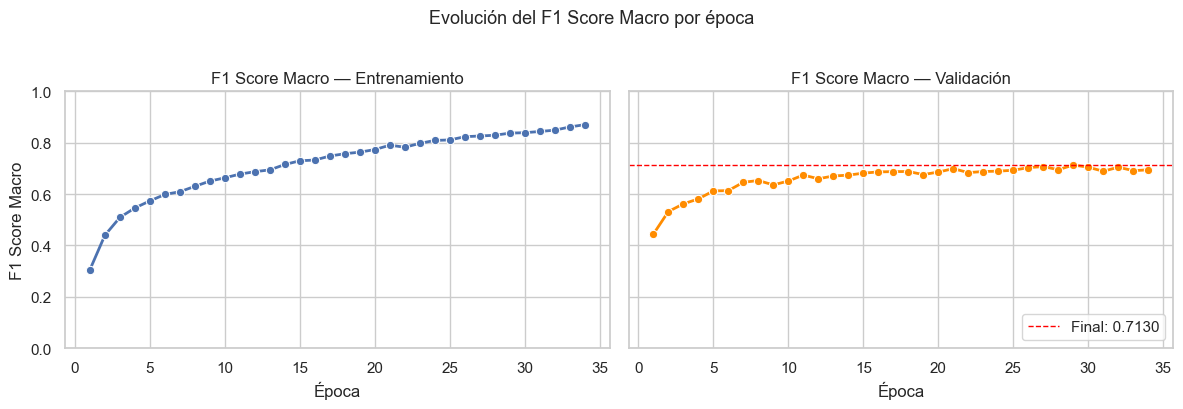

F1 Score Macro final en validación: 0.7130 (71.30%)


In [124]:
f1_final_val = metricas_val_final["val_f1"]
epocas = list(range(1, len(historial_entrenamiento["train_f1"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_f1"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("F1 Score Macro — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("F1 Score Macro")
axes[0].set_ylim(0, 1)

sns.lineplot(x=epocas, y=historial_entrenamiento["val_f1"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("F1 Score Macro — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Score Macro")
axes[1].set_ylim(0, 1)
axes[1].axhline(f1_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {f1_final_val:.4f}")
axes[1].legend(loc="lower right")

fig.suptitle("Evolución del F1 Score Macro por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"F1 Score Macro final en validación: {f1_final_val:.4f} ({f1_final_val * 100:.2f}%)")

### 3.3 Costo (Loss)

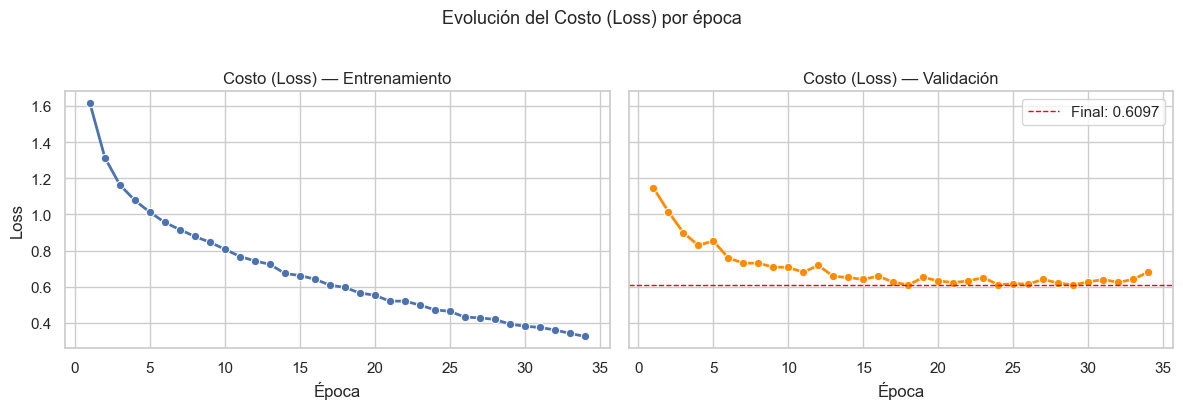

Costo (Loss) final en validación: 0.6097


In [125]:
loss_final_val = metricas_val_final["val_loss"]
epocas = list(range(1, len(historial_entrenamiento["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(x=epocas, y=historial_entrenamiento["train_loss"], ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Costo (Loss) — Entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")

sns.lineplot(x=epocas, y=historial_entrenamiento["val_loss"], ax=axes[1], marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Costo (Loss) — Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].axhline(loss_final_val, color="red", linestyle="--", linewidth=1, label=f"Final: {loss_final_val:.4f}")
axes[1].legend(loc="upper right")

fig.suptitle("Evolución del Costo (Loss) por época", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Costo (Loss) final en validación: {loss_final_val:.4f}")

### 3.4 Classification report

In [126]:
try:
    from sklearn.metrics import classification_report
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import classification_report

print("Classification report — validación (última época)\n")
print(
    classification_report(
        etiquetas_val_final,
        predicciones_val_final,
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

Classification report — validación (última época)

              precision    recall  f1-score   support

     alegria     0.9051    0.9013    0.9032      1185
    disgusto     0.5091    0.5250    0.5169       160
       enojo     0.7134    0.6914    0.7022       162
       miedo     0.6406    0.5541    0.5942        74
    seriedad     0.7622    0.7779    0.7700       680
    sorpresa     0.8119    0.7872    0.7994       329
    tristeza     0.6973    0.7134    0.7053       478

    accuracy                         0.7934      3068
   macro avg     0.7200    0.7072    0.7130      3068
weighted avg     0.7939    0.7934    0.7935      3068



### 3.5 Matrices de confusión.

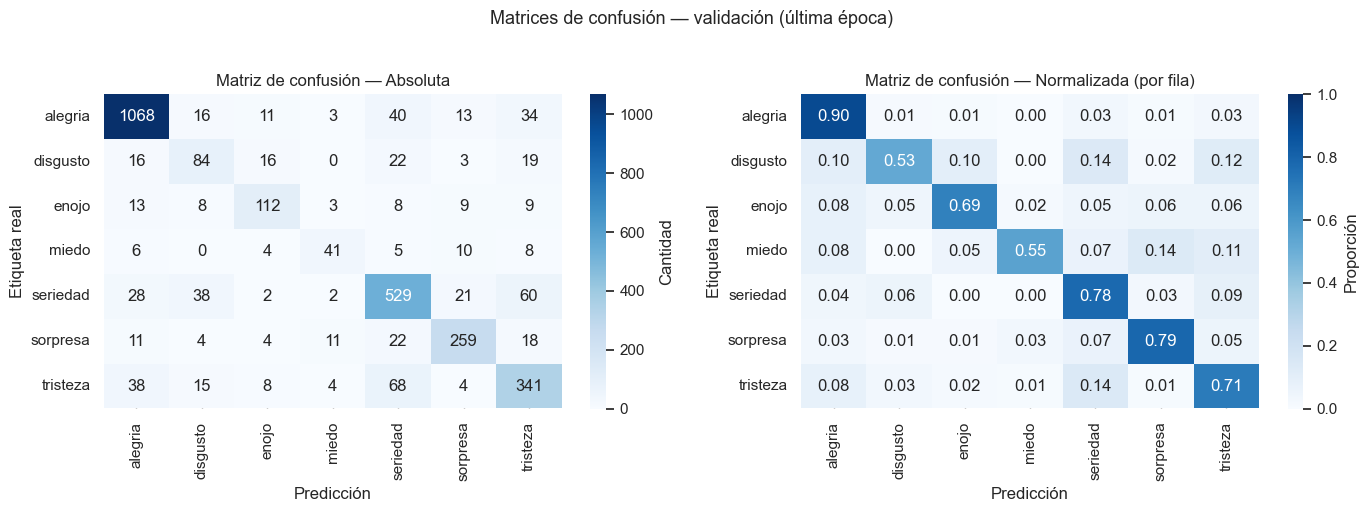

In [127]:
try:
    from sklearn.metrics import confusion_matrix
except ModuleNotFoundError:
    _pip_install("scikit-learn")
    from sklearn.metrics import confusion_matrix

try:
    import seaborn as sns
except ModuleNotFoundError:
    _pip_install("seaborn")
    import seaborn as sns

matriz_abs = confusion_matrix(etiquetas_val_final, predicciones_val_final)
matriz_norm = confusion_matrix(etiquetas_val_final, predicciones_val_final, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    matriz_abs,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar_kws={"label": "Cantidad"},
)
axes[0].set_title("Matriz de confusión — Absoluta")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Etiqueta real")

sns.heatmap(
    matriz_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    cbar_kws={"label": "Proporción"},
)
axes[1].set_title("Matriz de confusión — Normalizada (por fila)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Etiqueta real")

fig.suptitle("Matrices de confusión — validación (última época)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 Comentarios del entrenamiento (E6 — config final)

> **⚠️ REVISAR ANTES DE LA ENTREGA:** borrador con métricas E6. Ajustar redacción tras completar puntos 4 y 5.

**Resultado final (E6):** accuracy **79.34%**, F1 macro **71.30%**, loss **0.6097** (mejor época 29, early stop en 34).

**Campaña experimental (E0→E6):**
- **E1:** early stopping en `val_f1` alinea el checkpoint con la métrica de evaluación (+2.8 pp F1 vs E0).
- **E4:** resolución 64×64 aporta detalle facial; mejor config previa (69.7% F1).
- **E2 descartado:** sampler + loss ponderada juntos empeoraron (doble compensación).
- **E6:** loss `sqrt_inverso` **sin** sampler — mejor resultado global (+1.6 pp F1 vs E4).

**Por clase (E6):** alegría y sorpresa >0.80 F1; seriedad/tristeza/enojo ~0.70–0.77; miedo 0.59; disgusto 0.52 (clase más difícil).

**Confusiones persistentes:** tristeza↔seriedad (~14%), disgusto→seriedad (~14%), miedo→sorpresa (~12%). Parte del techo es semántico (expresiones parecidas) y de resolución.

**Overfitting:** train acc ~87% vs val acc ~79% en mejor época — patrón distinto al de configs con sampler (E4), donde el balanceo artificial inflaba train acc.

Detalle completo: `reporte-experimentos.md` y `conclusiones.md`.

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

In [ ]:
import io
import subprocess
import sys

EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
MIN_IMAGENES_PRUEBA = 12


def _seleccionar_imagenes_macos():
    """Diálogo nativo de macOS (evita crash de tkinter en Jupyter/Cursor)."""
    script = """
try
    set chosenFiles to choose file with prompt "Seleccionar al menos 12 imágenes (Cmd+clic para varias)" with multiple selections allowed
    set pathList to {}
    repeat with f in chosenFiles
        set end of pathList to POSIX path of f
    end repeat
    set AppleScript's text item delimiters to linefeed
    set outText to pathList as text
    set AppleScript's text item delimiters to ""
    return outText
on error number -128
    return ""
end try
"""
    result = subprocess.run(
        ["osascript", "-e", script],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0 and not result.stdout.strip():
        return []
    return [p for p in result.stdout.strip().splitlines() if p]


def _seleccionar_imagenes_ipywidgets():
    """Widget de carga para Jupyter cuando no hay diálogo nativo disponible."""
    try:
        import ipywidgets as widgets
        from IPython.display import clear_output, display
    except ModuleNotFoundError:
        _pip_install("ipywidgets")
        import ipywidgets as widgets
        from IPython.display import clear_output, display

    uploader = widgets.FileUpload(accept=".jpg,.jpeg,.png,.webp,.bmp", multiple=True)
    btn = widgets.Button(description="Continuar", button_style="success")
    estado = {"listo": False}

    def _continuar(_):
        estado["listo"] = True

    btn.on_click(_continuar)
    display(
        widgets.VBox([
            widgets.HTML(
                f"<b>Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes y luego presioná <i>Continuar</i></b>"
            ),
            uploader,
            btn,
        ])
    )

    import time

    while not estado["listo"]:
        time.sleep(0.1)

    imagenes = []
    for item in uploader.value:
        nombre = item["name"]
        if Path(nombre).suffix.lower() not in EXTENSIONES_IMAGEN:
            print(f"Archivo omitido (no es imagen): {nombre}")
            continue
        imagenes.append((nombre, Image.open(io.BytesIO(item["content"])).copy()))

    clear_output(wait=True)
    return imagenes


def _seleccionar_imagenes_interactivo():
    """Abre un diálogo para elegir una o más imágenes (Colab o entorno local)."""
    imagenes = []

    if IN_COLAB:
        from google.colab import files

        print(f"Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes en el diálogo de carga...")
        subidas = files.upload()
        for nombre, contenido in subidas.items():
            if Path(nombre).suffix.lower() not in EXTENSIONES_IMAGEN:
                print(f"Archivo omitido (no es imagen): {nombre}")
                continue
            imagenes.append((nombre, Image.open(io.BytesIO(contenido)).copy()))
    elif sys.platform == "darwin":
        print(f"Seleccioná al menos {MIN_IMAGENES_PRUEBA} imágenes en el diálogo del sistema...")
        rutas = _seleccionar_imagenes_macos()
        for ruta in rutas:
            p = Path(ruta)
            if p.suffix.lower() not in EXTENSIONES_IMAGEN:
                print(f"Archivo omitido (no es imagen): {p.name}")
                continue
            with Image.open(p) as img:
                imagenes.append((p.name, img.copy()))
    else:
        print("Usá el widget para cargar imágenes...")
        return _seleccionar_imagenes_ipywidgets()

    return imagenes


def _preguntar_reintentar():
    while True:
        respuesta = input("¿Desea reintentar? [Y/N]: ").strip().upper()
        if respuesta == "Y":
            return True
        if respuesta == "N":
            return False
        print("Respuesta no válida. Ingresá Y para reintentar o N para cancelar.")


def _cargar_imagenes_prueba():
    """Solicita imágenes hasta alcanzar el mínimo requerido o hasta que el usuario cancele."""
    while True:
        imagenes = _seleccionar_imagenes_interactivo()
        cantidad = len(imagenes)

        if cantidad >= MIN_IMAGENES_PRUEBA:
            return imagenes

        if cantidad == 0:
            print(
                f"No se seleccionaron imágenes. "
                f"Deben cargarse al menos {MIN_IMAGENES_PRUEBA} imágenes."
            )
        else:
            print(
                f"Se seleccionaron {cantidad} imágenes. "
                f"Deben cargarse al menos {MIN_IMAGENES_PRUEBA} imágenes."
            )

        if not _preguntar_reintentar():
            return None


def _tensor_a_imagen_display(tensor):
    t = tensor.detach().cpu().clone()
    if APLICAR_NORMALIZACION:
        for c in range(t.shape[0]):
            t[c] = t[c] * NORMALIZE_STD[c] + NORMALIZE_MEAN[c]
    t = t.clamp(0, 1)
    if t.shape[0] == 1:
        return t.squeeze(0).numpy(), "gray"
    return t.permute(1, 2, 0).numpy(), None


@torch.no_grad()
def _inferir_imagen(img_pil):
    model.eval()
    tensor = transform_val(img_pil).unsqueeze(0).to(device)
    logits = model(tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    clase_idx = int(probs.argmax())
    return tensor.squeeze(0), probs, clase_idx


imagenes_prueba = _cargar_imagenes_prueba()

if imagenes_prueba is None:
    print("Carga de imágenes cancelada por el usuario.")
else:
    print(f"Imágenes a evaluar: {len(imagenes_prueba)}")

    for nombre, img_original in imagenes_prueba:
        img_rgb = img_original.convert("RGB")

        tensor_proc, probs, clase_idx = _inferir_imagen(img_rgb)
        img_proc, cmap_proc = _tensor_a_imagen_display(tensor_proc)
        clase_predicha = class_names[clase_idx]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].imshow(img_original)
        axes[0].set_title(f"Original\n{nombre}")
        axes[0].axis("off")

        axes[1].imshow(img_proc, cmap=cmap_proc, vmin=0, vmax=1)
        axes[1].set_title("Pre-procesada\n(mismo pipeline que validación)")
        axes[1].axis("off")

        axes[2].barh(class_names, probs, color="steelblue")
        axes[2].set_xlim(0, 1)
        axes[2].set_xlabel("Score (probabilidad)")
        axes[2].set_title(
            f"Clase inferida: {clase_predicha}\n"
            f"Confianza: {probs[clase_idx] * 100:.1f}%"
        )
        axes[2].invert_yaxis()
        for i, p in enumerate(probs):
            axes[2].text(p + 0.01, i, f"{p * 100:.1f}%", va="center", fontsize=9)

        fig.suptitle(
            f"Inferencia — {nombre} → {clase_predicha} ({probs[clase_idx] * 100:.1f}%)",
            y=1.02,
            fontsize=13,
        )
        plt.tight_layout()
        plt.show()

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

### 5.1 Definición de función para la detección y recorte de rostros

In [ ]:
# --- Parámetros de detección Haar (ajustar según convenga) ---
SCALE_FACTOR = 1.1
MIN_NEIGHBORS = 6
MIN_SIZE = (30, 30)


def deteccion_y_recorte_rostro(imagen, scale_factor, min_neighbors, min_size):
    """
    Detecta rostros con Haar Cascade y recorta el primero en relación de aspecto 1:1.

    Parámetros
    ----------
    imagen : str, Path, np.ndarray (BGR) o PIL.Image
    scale_factor, min_neighbors, min_size : parámetros de detectMultiScale

    Retorna
    -------
    dict con:
        - imagen_deteccion_rgb: imagen original con cajas dibujadas (RGB)
        - rostro_recortado_rgb: recorte cuadrado del primer rostro (RGB) o None
        - faces: detecciones de OpenCV
        - detectado: bool
    """
    if isinstance(imagen, (str, Path)):
        image = cv2.imread(str(imagen))
        if image is None:
            raise ValueError(f"No se pudo leer la imagen: {imagen}")
    elif isinstance(imagen, Image.Image):
        image = cv2.cvtColor(np.array(imagen.convert("RGB")), cv2.COLOR_RGB2BGR)
    else:
        image = imagen.copy()

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size,
    )

    image_with_box = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cropped_face_rgb = None
    if len(faces) > 0:
        x, y, w, h = faces[0]
        center_x, center_y = x + w // 2, y + h // 2
        side = max(w, h)
        half_side = side // 2

        x1 = max(center_x - half_side, 0)
        y1 = max(center_y - half_side, 0)
        x2 = min(center_x + half_side, image.shape[1])
        y2 = min(center_y + half_side, image.shape[0])

        cropped_face = image[y1:y2, x1:x2]
        cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

    return {
        "imagen_deteccion_rgb": cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB),
        "rostro_recortado_rgb": cropped_face_rgb,
        "faces": faces,
        "detectado": len(faces) > 0,
    }


# --- Ejemplo de uso ---
image_path = ""

if image_path:
    resultado = deteccion_y_recorte_rostro(
        image_path, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE
    )

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(resultado["imagen_deteccion_rgb"])
    ax[0].set_title("Detección")
    ax[0].axis("off")

    if resultado["detectado"]:
        ax[1].imshow(resultado["rostro_recortado_rgb"])
        ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
        ax[1].axis("off")
    else:
        ax[1].text(
            0.5,
            0.5,
            "No se detectó rostro",
            horizontalalignment="center",
            verticalalignment="center",
        )
        ax[1].axis("off")

    plt.tight_layout()
    plt.show()


### 5.2 Detección y recorte de rostros en el set de imágenes

In [ ]:
if imagenes_prueba is None:
    print("Ejecutá primero la sección 4 y cargá al menos 12 imágenes.")
else:
    print(f"Aplicando detección y recorte de rostro a {len(imagenes_prueba)} imágenes...")

    for nombre, img_original in imagenes_prueba:
        resultado = deteccion_y_recorte_rostro(
            img_original, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE
        )

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(img_original)
        axes[0].set_title(f"Original\n{nombre}")
        axes[0].axis("off")

        if resultado["detectado"]:
            axes[1].imshow(resultado["rostro_recortado_rgb"])
            axes[1].set_title("Rostro recortado\n(relación 1:1)")
        else:
            axes[1].text(
                0.5,
                0.5,
                "No se detectó rostro",
                horizontalalignment="center",
                verticalalignment="center",
            )
            axes[1].set_title("Rostro recortado")
        axes[1].axis("off")

        fig.suptitle(f"Detección y recorte — {nombre}", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

### 5.3 Aplicacion de las mismas transformaciones que al set de validación

In [ ]:
if imagenes_prueba is None:
    print("Ejecutá primero la sección 4 y cargá al menos 12 imágenes.")
else:
    print(
        f"Aplicando transformaciones de validación a {len(imagenes_prueba)} rostros recortados..."
    )

    for nombre, img_original in imagenes_prueba:
        resultado = deteccion_y_recorte_rostro(
            img_original, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE
        )

        if not resultado["detectado"]:
            print(f"No se detectó rostro en: {nombre}")
            continue

        img_recortada = Image.fromarray(resultado["rostro_recortado_rgb"])
        tensor_proc = transform_val(img_recortada)
        img_proc, cmap_proc = _tensor_a_imagen_display(tensor_proc)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(resultado["rostro_recortado_rgb"])
        axes[0].set_title(f"Rostro recortado\n{nombre}")
        axes[0].axis("off")

        axes[1].imshow(img_proc, cmap=cmap_proc, vmin=0, vmax=1)
        axes[1].set_title("Pre-procesada\n(mismo pipeline que validación)")
        axes[1].axis("off")

        fig.suptitle(f"Transformaciones — {nombre}", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

### 5.4 Etiquetado de clase esperada

Seleccioná la emoción real de cada imagen y presioná **Guardar clases esperadas** antes de ejecutar la inferencia.


In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
except ModuleNotFoundError:
    _pip_install("ipywidgets")
    import ipywidgets as widgets
    from IPython.display import clear_output, display

if IN_COLAB:
    from google.colab import output

    output.enable_custom_widget_manager()

clases_esperadas_por_archivo = {}

if imagenes_prueba is None:
    print("Ejecutá primero la sección 4 y cargá al menos 12 imágenes.")
else:
    dropdowns = {}
    filas = []

    for nombre, _ in imagenes_prueba:
        dropdown = widgets.Dropdown(
            options=class_names,
            value=class_names[0],
            description="",
            layout=widgets.Layout(width="220px"),
        )
        dropdowns[nombre] = dropdown
        filas.append(
            widgets.HBox([
                widgets.HTML(f"<div style='width:220px'><b>{nombre}</b></div>"),
                dropdown,
            ])
        )

    btn_guardar = widgets.Button(
        description="Guardar clases esperadas",
        button_style="success",
    )
    salida = widgets.Output()

    def _guardar_clases_esperadas(_):
        with salida:
            clear_output(wait=True)
            clases_esperadas_por_archivo.clear()
            for nombre, dropdown in dropdowns.items():
                clases_esperadas_por_archivo[nombre] = dropdown.value
            print(
                f"Clases esperadas guardadas para "
                f"{len(clases_esperadas_por_archivo)} imágenes:"
            )
            for nombre, clase in clases_esperadas_por_archivo.items():
                print(f"  {nombre}: {clase}")

    btn_guardar.on_click(_guardar_clases_esperadas)

    display(
        widgets.VBox([
            widgets.HTML(
                "<b>Seleccioná la emoción esperada para cada imagen:</b>"
            ),
            *filas,
            btn_guardar,
            salida,
        ])
    )


In [ ]:
if "clases_esperadas_por_archivo" not in globals():
    clases_esperadas_por_archivo = {}

if imagenes_prueba is None:
    print("Ejecutá primero la sección 4 y cargá al menos 12 imágenes.")
else:
    print(
        f"Inferencia del modelo sobre {len(imagenes_prueba)} imágenes "
        f"(recorte + pre-procesamiento de validación)..."
    )

    for nombre, img_original in imagenes_prueba:
        resultado = deteccion_y_recorte_rostro(
            img_original, SCALE_FACTOR, MIN_NEIGHBORS, MIN_SIZE
        )

        if not resultado["detectado"]:
            print(f"No se detectó rostro en: {nombre}")
            continue

        img_recortada = Image.fromarray(resultado["rostro_recortado_rgb"])
        _, probs, clase_idx = _inferir_imagen(img_recortada.convert("RGB"))
        clase_predicha = class_names[clase_idx]
        clase_esperada = clases_esperadas_por_archivo.get(nombre)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(img_original)
        axes[0].set_title(f"Original\n{nombre}")
        axes[0].axis("off")

        titulo_scores = (
            f"Clase inferida: {clase_predicha}\n"
            f"Confianza: {probs[clase_idx] * 100:.1f}%"
        )
        if clase_esperada is not None:
            titulo_scores = f"Clase esperada: {clase_esperada}\n" + titulo_scores

        axes[1].barh(class_names, probs, color="steelblue")
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel("Score (probabilidad)")
        axes[1].set_title(titulo_scores)
        axes[1].invert_yaxis()
        for i, p in enumerate(probs):
            axes[1].text(p + 0.01, i, f"{p * 100:.1f}%", va="center", fontsize=9)

        acierto = (
            "✓" if clase_esperada is not None and clase_esperada == clase_predicha else ""
        )
        fig.suptitle(
            f"Inferencia — {nombre} → {clase_predicha} "
            f"({probs[clase_idx] * 100:.1f}%) {acierto}",
            y=1.02,
            fontsize=13,
        )
        plt.tight_layout()
        plt.show()
